In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl 
import pandas as pd 
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API"),
    base_url="https://api.groq.com/openai/v1"
)

df = pd.read_csv("..\preprocessing\data\cleaned_laptop_data.csv") 
df

,type_name,user_profile,budget_class,upgrade_first,gain_class,price,recommended_upgrade_cost_est,inches,weight_kg,opsys,...,gpu_urgency_score,performance_score,ram_gap_ratio,storage_gap_ratio,gpu_gap_ratio,upgrade_pressure,total_urgency,price_per_performance,storage_capacity_score,storage_speed_score
0,Ultrabook,student,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
1,Ultrabook,student,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
2,Ultrabook,student,high,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
3,Ultrabook,office,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
4,Ultrabook,office,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19540,Notebook,designer,medium,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.733,2.985060,0.705882,0.499500,0.555556,0.594156,0.880000,4933.506157,500,225.0
19541,Notebook,designer,high,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.919,2.985060,0.705882,0.499500,0.555556,0.594156,0.942000,4933.506157,500,225.0
19542,Notebook,gamer,low,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.446,2.985060,0.705882,0.023392,0.636364,0.507452,0.701333,4933.506157,500,225.0
19543,Notebook,gamer,medium,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.646,2.985060,0.705882,0.023392,0.636364,0.507452,0.768000,4933.506157,500,225.0


### Input Features

The system uses four inputs:

- total_urgency → overall need for upgrade  
- ram_gap_gb → how much RAM is missing  
- gpu_gap_score → how weak the GPU is  
- recommended_upgrade_cost_est → estimated cost  

These features were chosen because they represent need and cost.

In [2]:

total_urgency = ctrl.Antecedent(np.arange(0, 11, 1), "total_urgency")
ram_gap_gb = ctrl.Antecedent(np.arange(0, 33, 1), "ram_gap_gb")
gpu_gap_score = ctrl.Antecedent(np.arange(0, 101, 1), "gpu_gap_score")
upgrade_cost = ctrl.Antecedent(np.arange(0, 2001, 50), "upgrade_cost")

# Output
upgrade_decision = ctrl.Consequent(np.arange(0, 101, 1), "upgrade_decision")

### Membership Functions

Each input is divided into levels such as low, medium, and high. This allows the system to handle gradual changes instead of strict thresholds.

In [3]:
total_urgency["low"] = fuzz.trimf(total_urgency.universe, [0, 0, 4])
total_urgency["medium"] = fuzz.trimf(total_urgency.universe, [2, 5, 8])
total_urgency["high"] = fuzz.trimf(total_urgency.universe, [6, 10, 10])

ram_gap_gb["low"] = fuzz.trimf(ram_gap_gb.universe, [0, 0, 8])
ram_gap_gb["medium"] = fuzz.trimf(ram_gap_gb.universe, [4, 12, 20])
ram_gap_gb["high"] = fuzz.trimf(ram_gap_gb.universe, [16, 32, 32])

gpu_gap_score["low"] = fuzz.trimf(gpu_gap_score.universe, [0, 0, 35])
gpu_gap_score["medium"] = fuzz.trimf(gpu_gap_score.universe, [25, 50, 75])
gpu_gap_score["high"] = fuzz.trimf(gpu_gap_score.universe, [65, 100, 100])

upgrade_cost["low"] = fuzz.trimf(upgrade_cost.universe, [0, 0, 600])
upgrade_cost["medium"] = fuzz.trimf(upgrade_cost.universe, [400, 900, 1400])
upgrade_cost["high"] = fuzz.trimf(upgrade_cost.universe, [1200, 2000, 2000])

upgrade_decision["low"] = fuzz.trimf(upgrade_decision.universe, [0, 0, 30])
upgrade_decision["medium"] = fuzz.trimf(upgrade_decision.universe, [20, 45, 65])
upgrade_decision["high"] = fuzz.trimf(upgrade_decision.universe, [55, 75, 90])
upgrade_decision["critical"] = fuzz.trimf(upgrade_decision.universe, [80, 100, 100])

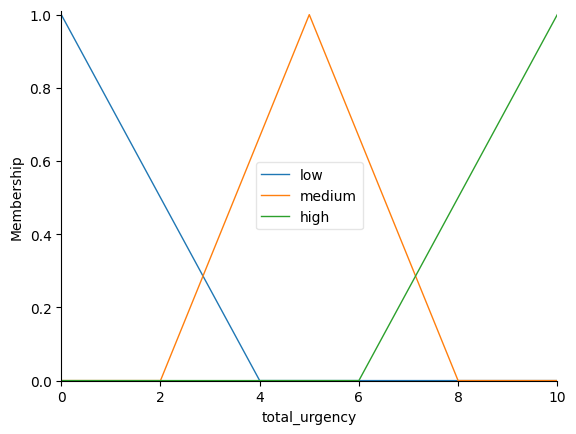

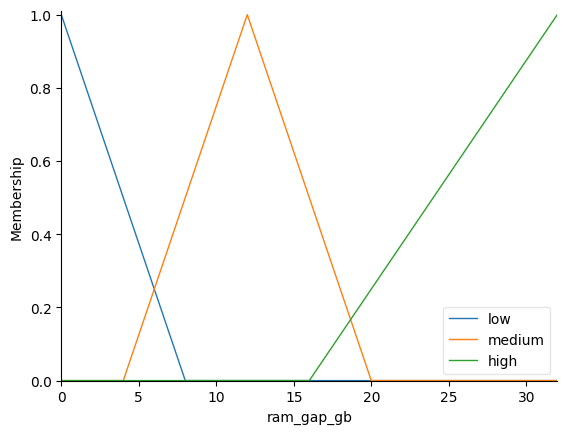

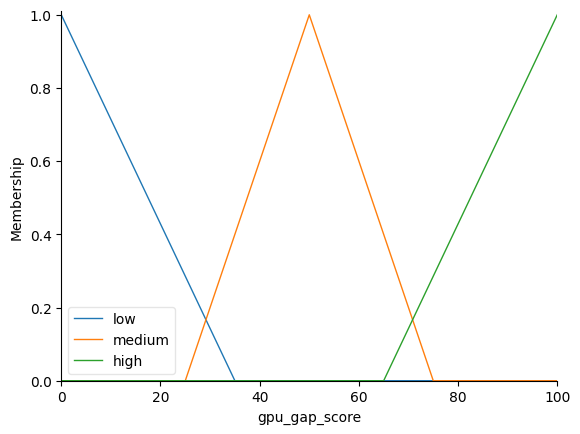

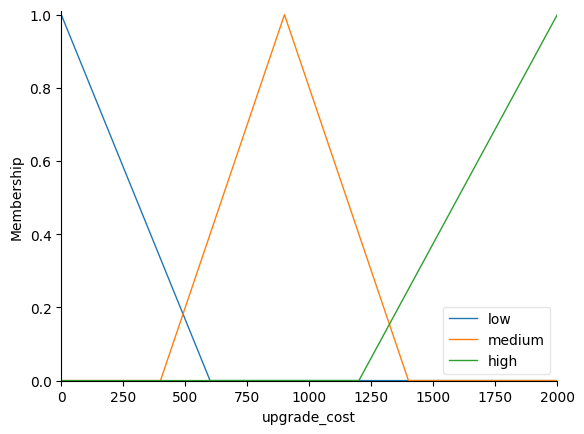

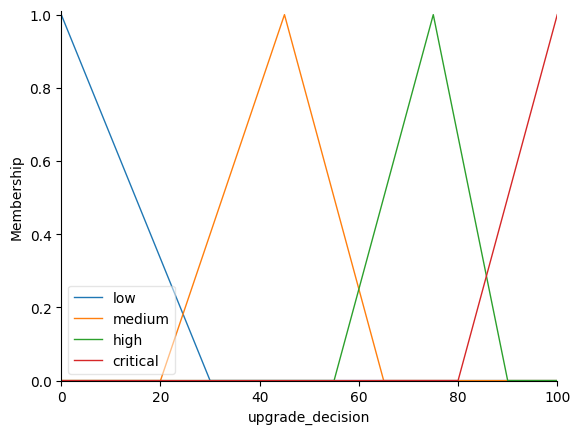

In [16]:
total_urgency.view()
ram_gap_gb.view()
gpu_gap_score.view()
upgrade_cost.view()
upgrade_decision.view()

In [5]:
rule1 = ctrl.Rule(
    total_urgency["low"] & ram_gap_gb["low"] & gpu_gap_score["low"],
    upgrade_decision["low"]
)

rule2 = ctrl.Rule(
    total_urgency["medium"] | ram_gap_gb["medium"],
    upgrade_decision["medium"]
)

rule3 = ctrl.Rule(
    total_urgency["high"] & ram_gap_gb["medium"],
    upgrade_decision["high"]
)

rule4 = ctrl.Rule(
    total_urgency["high"] & gpu_gap_score["high"],
    upgrade_decision["critical"]
)

rule5 = ctrl.Rule(
    ram_gap_gb["high"] & total_urgency["high"],
    upgrade_decision["critical"]
)

rule6 = ctrl.Rule(
    gpu_gap_score["high"] & total_urgency["medium"],
    upgrade_decision["high"]
)

rule7 = ctrl.Rule(
    upgrade_cost["high"] & total_urgency["low"],
    upgrade_decision["medium"]
)

rule8 = ctrl.Rule(
    upgrade_cost["high"] & total_urgency["high"],
    upgrade_decision["high"]
)

rule9 = ctrl.Rule(
    upgrade_cost["low"] & total_urgency["high"],
    upgrade_decision["critical"]
)

rule10 = ctrl.Rule(
    ram_gap_gb["medium"] & gpu_gap_score["medium"],
    upgrade_decision["medium"]
)

In [6]:
upgrade_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5,
    rule6, rule7, rule8, rule9, rule10
])

In [13]:
def explain_fuzzy_result_llm(
    total_urgency_value,
    ram_gap_value,
    gpu_gap_value,
    upgrade_cost_value,
    fuzzy_score,
    label,
    model="llama-3.1-8b-instant"
):
    prompt = f"""
You are explaining a fuzzy logic laptop upgrade decision to a non-technical user.

Fuzzy system inputs:
- Total urgency: {total_urgency_value}
- RAM gap in GB: {ram_gap_value}
- GPU gap score: {gpu_gap_value}
- Estimated upgrade cost: {upgrade_cost_value}
- Final fuzzy score: {fuzzy_score}
- Final fuzzy label: {label}

Explain why the fuzzy system gave this result.

Rules:
- Keep it short, 3 to 5 sentences.
- Use simple language.
- Do not mention code.
- Do not invent extra data.
- Base the explanation only on the given inputs.
"""

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "You are a helpful AI assistant that explains laptop upgrade decisions clearly."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0.3,
            max_tokens=180
        )

        return response.choices[0].message.content.strip()

    except Exception as e:
        return (
            f"The fuzzy system classified this laptop as '{label}'. "
            f"This decision was based on urgency={total_urgency_value}, "
            f"RAM gap={ram_gap_value}GB, GPU gap={gpu_gap_value}, "
            f"and estimated upgrade cost={upgrade_cost_value}. "
            f"LLM explanation was unavailable because: {e}"
        )

In [14]:
def run_fuzzy_upgrade_evaluator(
    total_urgency_value,
    ram_gap_value,
    gpu_gap_value,
    upgrade_cost_value
):
    simulator = ctrl.ControlSystemSimulation(upgrade_ctrl)

    simulator.input["total_urgency"] = total_urgency_value
    simulator.input["ram_gap_gb"] = ram_gap_value
    simulator.input["gpu_gap_score"] = gpu_gap_value
    simulator.input["upgrade_cost"] = upgrade_cost_value

    simulator.compute()

    score = simulator.output["upgrade_decision"]
    label = get_upgrade_label(score)

    explanation = explain_fuzzy_result_llm(
        total_urgency_value=total_urgency_value,
        ram_gap_value=ram_gap_value,
        gpu_gap_value=gpu_gap_value,
        upgrade_cost_value=upgrade_cost_value,
        fuzzy_score=round(score, 2),
        label=label
    )

    return {
        "fuzzy_score": round(score, 2),
        "fuzzy_label": label,
        "fuzzy_explanation": explanation
    }

In [15]:
result = run_fuzzy_upgrade_evaluator(
    total_urgency_value=8,
    ram_gap_value=16,
    gpu_gap_value=75,
    upgrade_cost_value=950
)

result

{'fuzzy_score': np.float64(60.09),
 'fuzzy_label': 'High Upgrade Need',
 'fuzzy_explanation': "The fuzzy system analyzed your laptop upgrade needs and gave a final score of 60.09, which means you have a High Upgrade Need. This is because your system has a high urgency level of 8, indicating you need to upgrade soon. Additionally, your RAM is 16 GB short, which is a significant gap, and your GPU is 75 points behind, which suggests your laptop's graphics capabilities are not up to par. The estimated cost of $950 is also considered in the decision, but it's not the main factor in this case."}